# Business Communication & Insights

## Executive Summary

Von 3333 bereinigten Kunden sind 14.49% abgewandert. Fuer die Plakatkampagne sind **Jacksonville
(29.82% Churn-Rate), Orlando1 (23.67%), Cape Coral (21.78%) und Orlando2 (19.08%)** die klaren
Prioritaeten — zusammen tragen sie 60.9% aller Abwanderungen. Fuer den Individualkontakt liefert
`international_plan` das staerkste Signal: Kunden mit diesem Vertrag wandern zu 42.4% ab
(vs. 11.5% ohne) — 323 betroffene Kunden. `customer_service_calls` ist ein guter Fruehindikator:
die Churn-Rate springt ab 4 Anrufen von ~10% auf ueber 45%, weshalb wir den Grenzwert bei 3 Anrufen
ansetzen (696 Kunden). Die logistische Regression auf `total_day_minutes` liefert einen statistisch
sauberen, aber sehr hohen Grenzwert von 350.74 Minuten und betrifft nur 4 Kunden — als alleiniger
Indikator zu schwach (Pseudo-R² 0.052), aber sinnvoll als Zusatzkriterium. Insgesamt haben 954 von
3333 Kunden mindestens einen der drei Risiko-Indikatoren.

## Key Visualizations

> _Die 3-5 wichtigsten Erkenntnisse als saubere Charts._

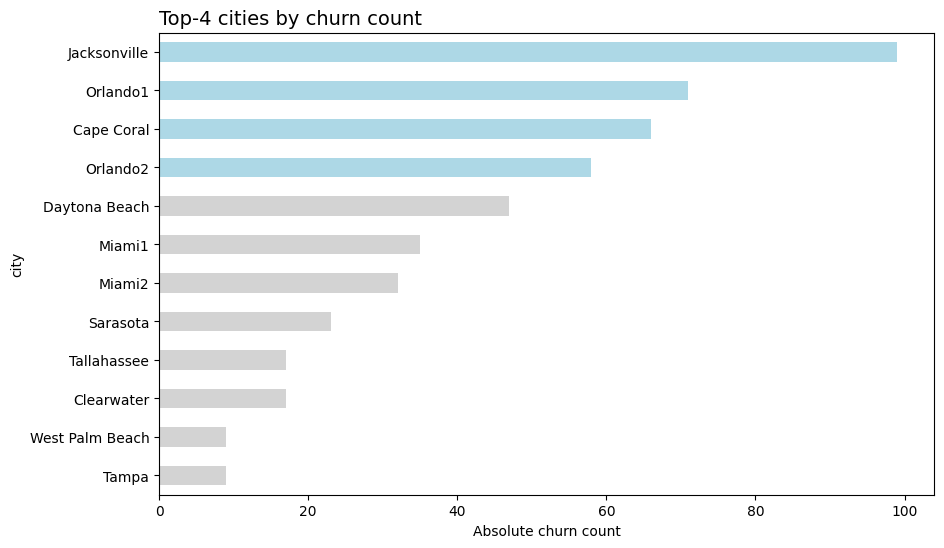

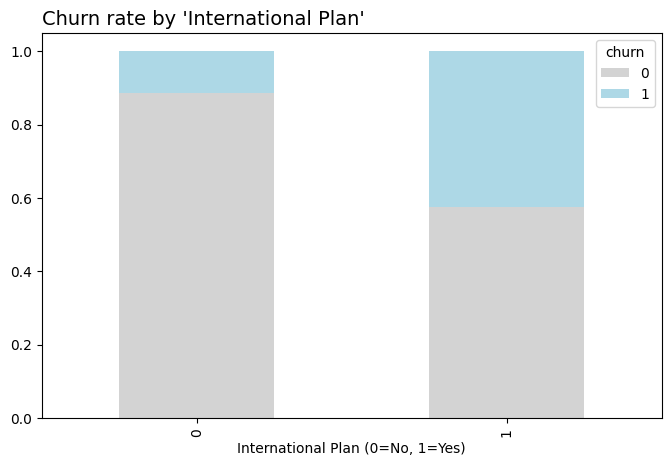

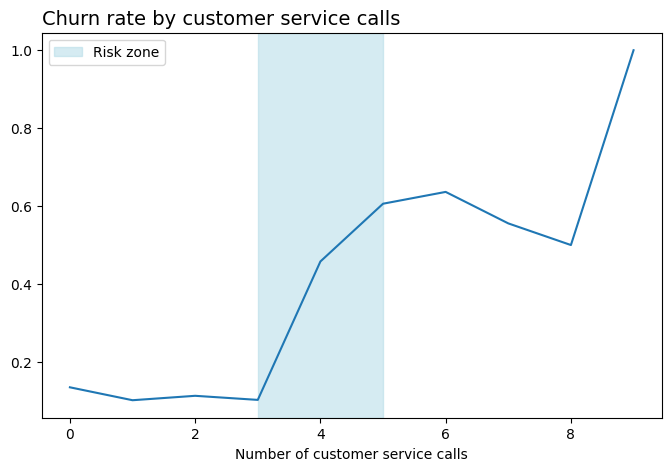

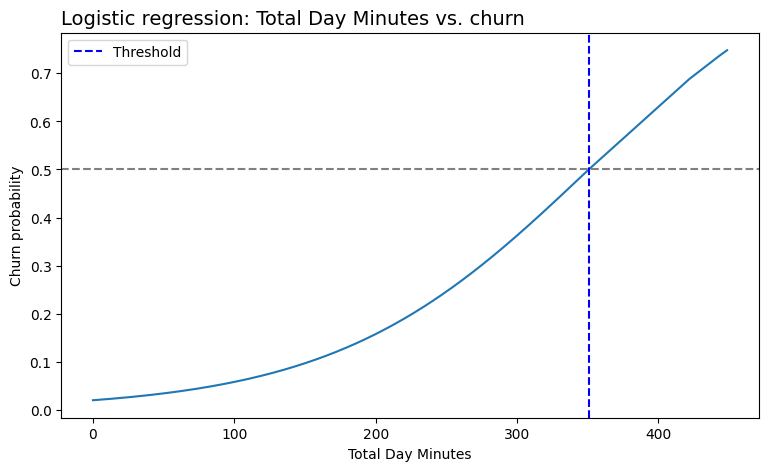

Threshold total_day_minutes: 350.74


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.formula.api as smf
from pathlib import Path

DATA_PROCESSED = Path('../data/processed')
FIGURES = Path('../public/img')
FIGURES.mkdir(parents=True, exist_ok=True)

df_clean = pd.read_csv(DATA_PROCESSED / 'telco_churn_clean.csv')

# --- Chart 1: City ranking (churn count) ---
# Sorted by churn_cnt_1 to match the top-4 selection criterion used in 03_analysis
# for the poster campaign (absolute churn count, not rate).
churn_city_counts = pd.crosstab(df_clean['city'], df_clean['churn'])
churn_city_percents = round(pd.crosstab(df_clean['city'], df_clean['churn'], normalize='index') * 100, 2)
churn_city_summary = pd.DataFrame({
    'churn_cnt_1': churn_city_counts[1],
    'churn_pct_1': churn_city_percents[1],
}).sort_values('churn_cnt_1', ascending=False)

data = churn_city_summary['churn_cnt_1'].sort_values(ascending=True)
colors = ['lightgray'] * (len(data) - 4) + ['lightblue'] * 4
fig, ax = plt.subplots(figsize=(10, 6))
data.plot(kind='barh', color=colors, ax=ax)
ax.set_title('Top-4 cities by churn count', loc='left', fontsize=14)
ax.set_xlabel('Absolute churn count')
fig.savefig(FIGURES / 'city_churn_ranking.png', bbox_inches='tight', dpi=150)
plt.show()

# --- Chart 2: International Plan ---
ct_intplan_churn = pd.crosstab(df_clean['international_plan'], df_clean['churn'], normalize='index')
fig, ax = plt.subplots(figsize=(8, 5))
ct_intplan_churn.plot(kind='bar', stacked=True, color=['lightgray', 'lightblue'], ax=ax)
ax.set_title("Churn rate by 'International Plan'", loc='left', fontsize=14)
ax.set_xlabel('International Plan (0=No, 1=Yes)')
fig.savefig(FIGURES / 'international_plan_churn.png', bbox_inches='tight', dpi=150)
plt.show()

# --- Chart 3: Customer Service Calls ---
csc_churn_rate = df_clean.groupby('customer_service_calls')['churn'].mean().reset_index()
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(csc_churn_rate['customer_service_calls'], csc_churn_rate['churn'])
ax.axvspan(3, 5, color='lightblue', alpha=0.5, label='Risk zone')
ax.set_title('Churn rate by customer service calls', loc='left', fontsize=14)
ax.set_xlabel('Number of customer service calls')
ax.legend()
fig.savefig(FIGURES / 'customer_service_calls_churn.png', bbox_inches='tight', dpi=150)
plt.show()

# --- Chart 4: Logistic Regression Total Day Minutes ---
model = smf.logit(formula='churn ~ total_day_minutes', data=df_clean)
result = model.fit(disp=0)
intercept = result.params['Intercept']
coef = result.params['total_day_minutes']
threshold = -intercept / coef

tdm_plot_df = df_clean[['total_day_minutes']].copy().sort_values('total_day_minutes')
tdm_plot_df['churn_prob'] = 1 / (1 + np.exp(-(intercept + coef * tdm_plot_df['total_day_minutes'])))

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(tdm_plot_df['total_day_minutes'], tdm_plot_df['churn_prob'])
ax.axvline(threshold, color='blue', linestyle='--', label='Threshold')
ax.axhline(0.5, color='gray', linestyle='--')
ax.set_title('Logistic regression: Total Day Minutes vs. churn', loc='left', fontsize=14)
ax.set_xlabel('Total Day Minutes')
ax.set_ylabel('Churn probability')
ax.legend()
fig.savefig(FIGURES / 'logit_total_day_minutes.png', bbox_inches='tight', dpi=150)
plt.show()

print(f"Threshold total_day_minutes: {threshold:.2f}")

## Recommendations

| Empfehlung | Betroffene Kunden | Prioritaet | Aufwand |
|------------|--------------------|------------|---------|
| Plakatkampagne in Jacksonville, Orlando1, Cape Coral, Orlando2 starten | 60.9% aller Abwanderungen | Hoch | Mittel (Media-Buchung) |
| Kunden mit `international_plan` individuell kontaktieren (Sonderkonditionen Ausland) | 323 Kunden, 42.4% Churn-Rate | Hoch | Niedrig (Filterliste vorhanden) |
| Kunden ab 3 `customer_service_calls` als Fruehwarnung kontaktieren | 696 Kunden | Mittel | Niedrig |
| Kunden ueber dem Logit-Grenzwert (350.74 Min.) bei `total_day_minutes` als Zusatzkriterium kontaktieren | 4 Kunden | Niedrig | Niedrig |

Kombiniert erreichen die drei Individualkontakt-Kriterien 954 von 3333 Kunden (mindestens ein
Indikator zutreffend) — Details siehe `03_analysis`, Abschnitt "Zusammenfassung".

## Next Steps & Open Questions

* Kampagnen-Erfolg messen (A/B-Test: kontaktierte vs. nicht-kontaktierte Risiko-Kunden)
* Ueberschneidung der drei Indikatoren als kombinierter Risiko-Score statt getrennter Schwellen pruefen
* `Orlando1`/`Orlando2` und `Miami1`/`Miami2` sind separate Eintraege fuer dieselbe Metropolregion (unterschiedliche Area Codes) — falls die Plakatkampagne pro Metro-Region statt pro Area-Code geplant wird, vorher pruefen ob eine Zusammenfassung das Top-4-Ranking veraendert

---

> **Export:** Datei -> Export -> HTML fuer Stakeholder-Report ohne Code-Zellen.